# 📊 EDA de la Recaudación Tributaria – Ecuador (Enero 2026)

## Basado en el dataset “sri_recaudacion_2026.csv”.

## 🔎 1. Estructura del Dataset
El archivo contiene las siguientes columnas claves:

- ANIO – Año del registro (2026)
- MES – Fecha de la recaudación (1-ene)
- GRUPO_IMPUESTO
- SUBGRUPO_IMPUESTO
- IMPUESTO
- GRAN_CONTRIBUYENTE (Sí/No)
- CODIGO_OPERA_FAMILIA
- TIPO_CONTRIBUYENTE – Personas naturales, sociedades, o “no tiene”
- PROVINCIA
- CANTON
- VALOR_RECAUDADO – Monto en USD (con formato latino)

Estos metadatos permiten un análisis multivariado: geográfico, por tipo de impuesto, por contribuyente, por categoría de operación, etc.

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import linear_model
import seaborn as sns
import geopandas as gpd

# Estilo gráfico profesional
sns.set(style="whitegrid", palette="dark", font_scale=1.2)

In [72]:
#pip install geopandas[all]

In [74]:
import pandas as pd

fname = 'sri_recaudacion_2026.csv'
df = pd.read_csv(fname, sep=';', dtype=str, encoding="latin1")

month_map = {
    'ene':'01','feb':'02','mar':'03','abr':'04','may':'05','jun':'06',
    'jul':'07','ago':'08','sep':'09','oct':'10','nov':'11','dic':'12'
}

split_mes = df['MES'].str.split('-', expand=True)
df['DIA'] = split_mes[0]

mes_abbr = split_mes[1].str.lower()
df['MES_NUM'] = mes_abbr.map(month_map)

df['FECHA'] = pd.to_datetime(df['ANIO'] + '-' + df['MES_NUM'] + '-' + df['DIA'], errors='coerce')

df_clean = df.copy()

output_name = 'sri_recaudacion_2026_clean.csv'
df_clean.to_csv(output_name, index=False)

output_name

'sri_recaudacion_2026_clean.csv'

In [75]:
df = pd.read_csv("sri_recaudacion_2026_clean.csv", sep=",", encoding="latin1")

df.head(2)

,ANIO,MES,GRUPO_IMPUESTO,SUBGRUPO_IMPUESTO,IMPUESTO,GRAN_CONTRIBUYENTE,CODIGO_OPERA_FAMILIA,TIPO_CONTRIBUYENTE,PROVINCIA,CANTON,VALOR_RECAUDADO,DIA,MES_NUM,FECHA
0,2026,1-ene,MULTAS TRIBUTARIAS,MULTAS TRIBUTARIAS (MTR),MULTAS TRIBUTARIAS,NO,M,PERSONAS NATURALES,GUAYAS,GUAYAQUIL,"75.616,61",1,1,2026-01-01
1,2026,1-ene,INTERESES TRIBUTARIOS,INTERES POR MORA TRIBUTARIA,INTERESES POR MORA TRIBUTARIOS,NO,M,PERSONAS NATURALES,COTOPAXI,LATACUNGA,"271,88",1,1,2026-01-01


In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58717 entries, 0 to 58716
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   ANIO                  58717 non-null  int64 
 1   MES                   58717 non-null  object
 2   GRUPO_IMPUESTO        58717 non-null  object
 3   SUBGRUPO_IMPUESTO     58717 non-null  object
 4   IMPUESTO              58717 non-null  object
 5   GRAN_CONTRIBUYENTE    58717 non-null  object
 6   CODIGO_OPERA_FAMILIA  58717 non-null  object
 7   TIPO_CONTRIBUYENTE    58717 non-null  object
 8   PROVINCIA             58717 non-null  object
 9   CANTON                58717 non-null  object
 10  VALOR_RECAUDADO       58717 non-null  object
 11  DIA                   58717 non-null  int64 
 12  MES_NUM               58717 non-null  int64 
 13  FECHA                 58717 non-null  object
dtypes: int64(3), object(11)
memory usage: 6.3+ MB


In [77]:
# Convertir fechas
df["ANIO"] = pd.to_datetime(df["ANIO"], format="%Y")

In [78]:
#Eliminar columnas duplicadas por registros repetidos
df = df.drop_duplicates()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58717 entries, 0 to 58716
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   ANIO                  58717 non-null  datetime64[ns]
 1   MES                   58717 non-null  object        
 2   GRUPO_IMPUESTO        58717 non-null  object        
 3   SUBGRUPO_IMPUESTO     58717 non-null  object        
 4   IMPUESTO              58717 non-null  object        
 5   GRAN_CONTRIBUYENTE    58717 non-null  object        
 6   CODIGO_OPERA_FAMILIA  58717 non-null  object        
 7   TIPO_CONTRIBUYENTE    58717 non-null  object        
 8   PROVINCIA             58717 non-null  object        
 9   CANTON                58717 non-null  object        
 10  VALOR_RECAUDADO       58717 non-null  object        
 11  DIA                   58717 non-null  int64         
 12  MES_NUM               58717 non-null  int64         
 13  FECHA           

In [79]:

df["VALOR_RECAUDADO"] = (
    df["VALOR_RECAUDADO"].str.replace(".", "", regex=False)
                         .str.replace(",", ".", regex=False)
                         .astype(float)
)

## Top 10 de impuestos

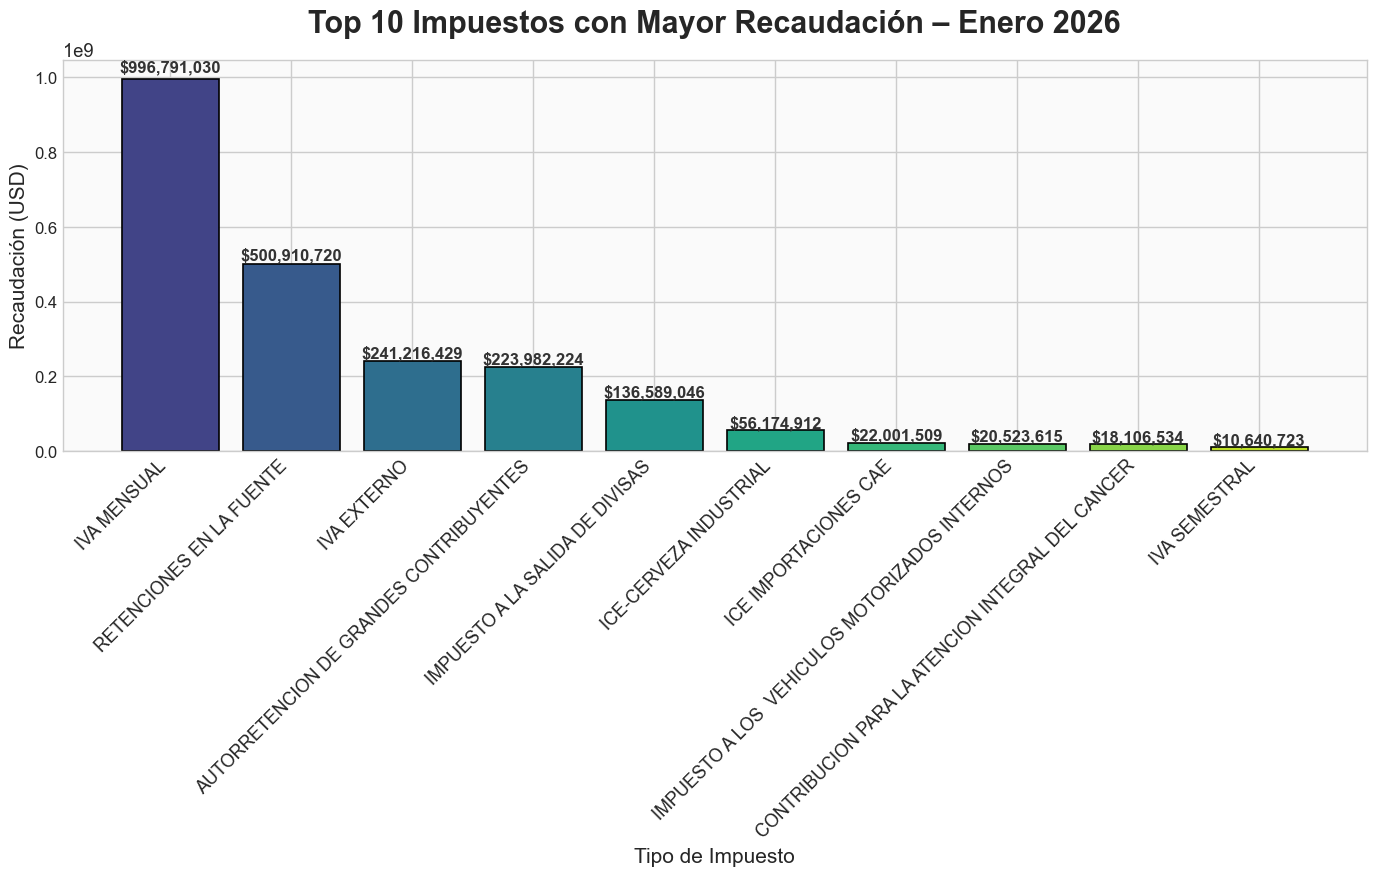

Gráfico guardado como: top10_impuestos_estilizado.png


In [80]:

# === CONFIGURACIÓN DE ESTILO ===
plt.style.use("seaborn-v0_8-whitegrid")

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.facecolor'] = 'white'

# === 4. Calcular Top 10 impuestos ===
top10 = (
    df.groupby("IMPUESTO")["VALOR_RECAUDADO"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

fig, ax = plt.subplots(figsize=(14, 9))

# Crear un gradiente de colores moderno
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(top10)))

bars = ax.bar(top10.index, top10.values, color=colors, 
              edgecolor="black", linewidth=1.2)

ax.set_title(
    "Top 10 Impuestos con Mayor Recaudación – Enero 2026",
    fontsize=22, fontweight="bold", pad=20
)

ax.set_ylabel("Recaudación (USD)", fontsize=15)
ax.set_xlabel("Tipo de Impuesto", fontsize=15)

plt.xticks(rotation=45, ha="right", fontsize=13)
plt.yticks(fontsize=12)

ax.set_facecolor("#FAFAFA")

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + (height * 0.01),
        f"${height:,.0f}",
        ha="center", va="bottom",
        fontsize=12, fontweight="bold", color="#333"
    )

plt.tight_layout()

plt.savefig("top10_impuestos_estilizado.png", dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico guardado como: top10_impuestos_estilizado.png")


## Recaudación 10 mejores provincias

C:\Users\mmunoz\AppData\Local\Temp\ipykernel_26716\2340761028.py:51: UserWarning: Glyph 129 (\x81) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\mmunoz\AppData\Local\Temp\ipykernel_26716\2340761028.py:53: UserWarning: Glyph 129 (\x81) missing from font(s) Arial.
  plt.savefig("recaudacion_total_por_provincia_estilizado.png", dpi=300, bbox_inches="tight")
C:\Users\mmunoz\AppData\Local\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129 (\x81) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


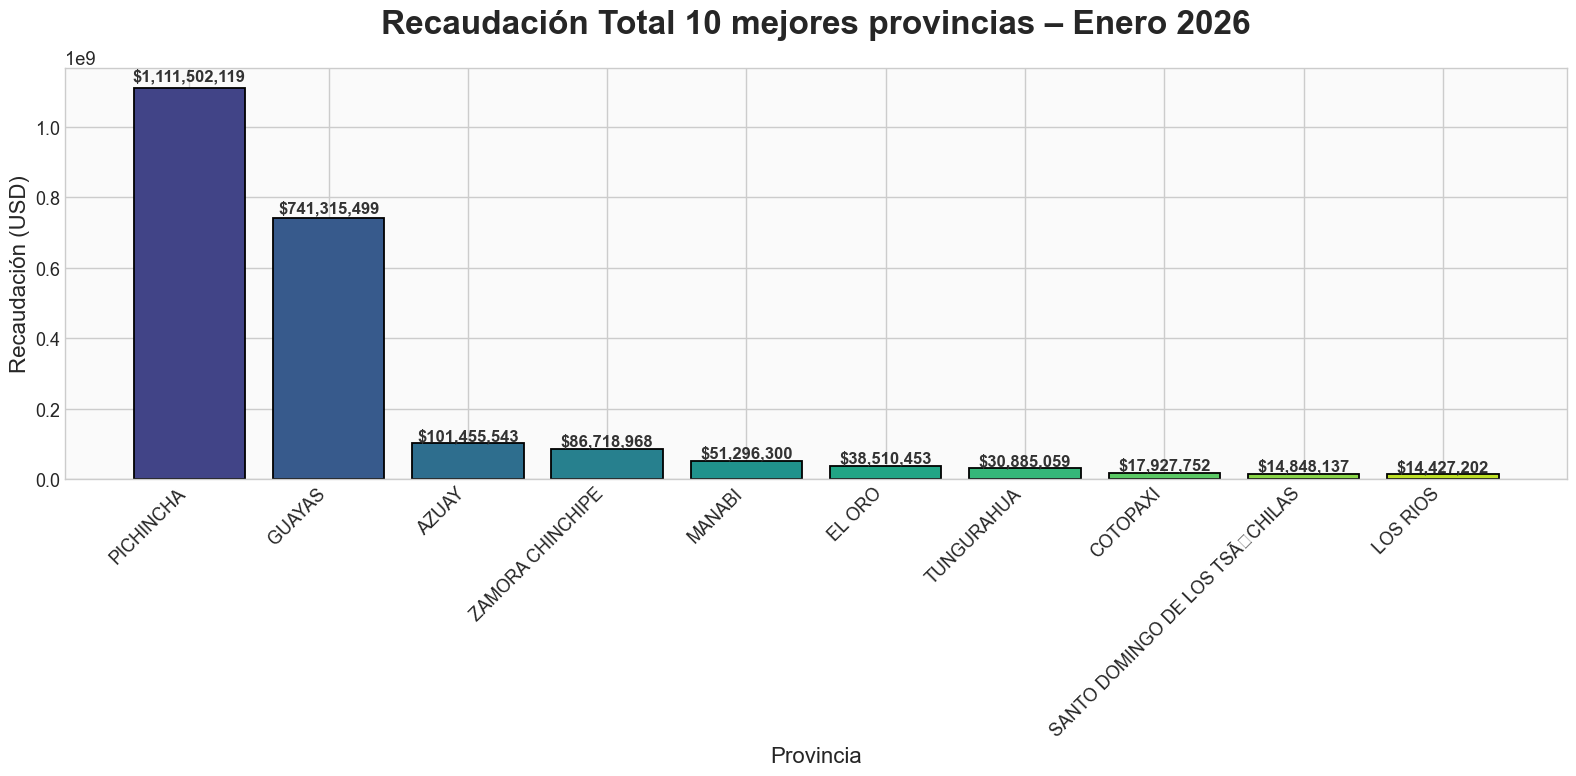

Gráfico guardado como: recaudacion_total_por_provincia_estilizado.png


In [81]:
plt.style.use("seaborn-v0_8-whitegrid")

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.facecolor'] = 'white'

#Agrupar recaudación por provincia
prov = (
    df.groupby("PROVINCIA")["VALOR_RECAUDADO"]
      .sum()
      .sort_values(ascending=False).head(10)
)


fig, ax = plt.subplots(figsize=(16, 8))


colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(prov)))

bars = ax.bar(prov.index, prov.values, color=colors, 
              edgecolor="black", linewidth=1.3)


ax.set_title(
    "Recaudación Total 10 mejores provincias – Enero 2026",
    fontsize=24, fontweight="bold", pad=25
)


ax.set_ylabel("Recaudación (USD)", fontsize=16)
ax.set_xlabel("Provincia", fontsize=16)

plt.xticks(rotation=45, ha="right", fontsize=13)
plt.yticks(fontsize=13)


ax.set_facecolor("#FAFAFA")


for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + (height * 0.01),
        f"${height:,.0f}",
        ha="center", va="bottom",
        fontsize=12, fontweight="bold", color="#333"
    )

plt.tight_layout()

plt.savefig("recaudacion_total_por_provincia_estilizado.png", dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico guardado como: recaudacion_total_por_provincia_estilizado.png")

## Recaudación: Personas Naturales vs Sociedades

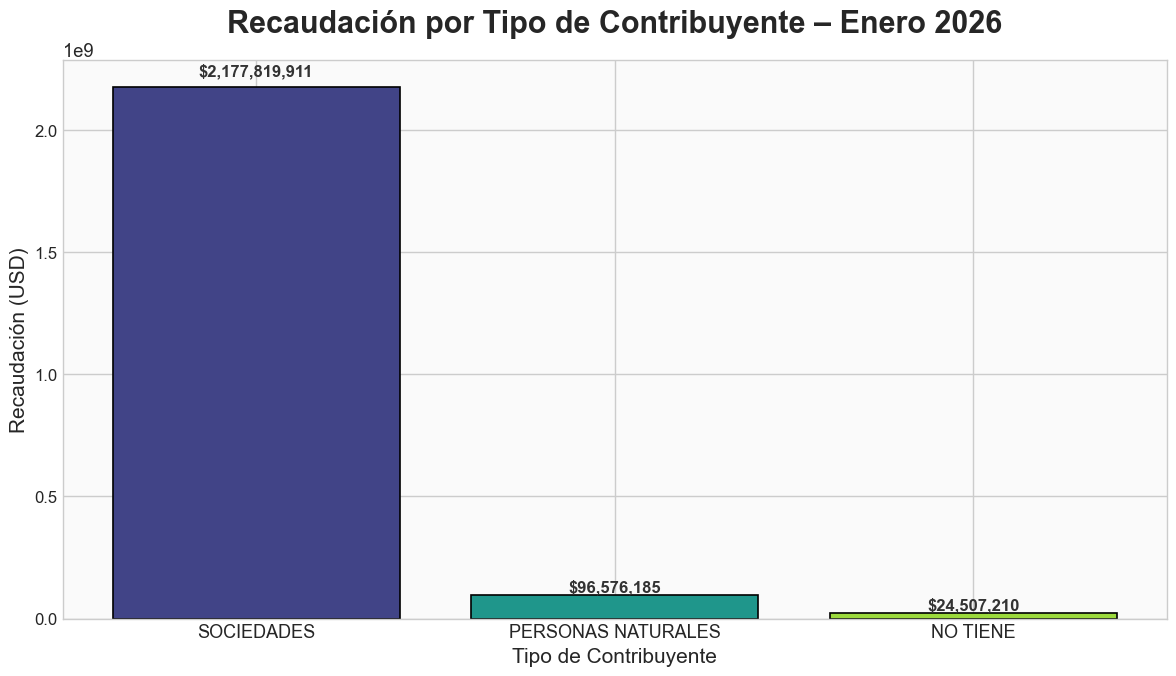

Gráfico guardado como: recaudacion_contribuyentes_estilizado.png


In [82]:

plt.style.use("seaborn-v0_8-whitegrid")

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.facecolor'] = 'white'

#Agrupar por tipo de contribuyente
tipo = (
    df.groupby("TIPO_CONTRIBUYENTE")["VALOR_RECAUDADO"]
      .sum()
      .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 7))

colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(tipo)))

bars = ax.bar(tipo.index, tipo.values,
              color=colors, edgecolor="black", linewidth=1.2)

ax.set_title(
    "Recaudación por Tipo de Contribuyente – Enero 2026",
    fontsize=22, fontweight="bold", pad=20
)

ax.set_ylabel("Recaudación (USD)", fontsize=15)
ax.set_xlabel("Tipo de Contribuyente", fontsize=15)

plt.xticks(rotation=0, fontsize=13)
plt.yticks(fontsize=12)

ax.set_facecolor("#FAFAFA")

# Etiquetas encima de las barras
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + (height * 0.015),
        f"${height:,.0f}",
        ha="center", va="bottom",
        fontsize=12, fontweight="bold", color="#333"
    )

plt.tight_layout()

plt.savefig("recaudacion_contribuyentes_estilizado.png", dpi=300, bbox_inches="tight")
plt.show()

print("Gráfico guardado como: recaudacion_contribuyentes_estilizado.png")

## Multas e Intereses - 10 Provincias (Enero 2026)

C:\Users\mmunoz\AppData\Local\Temp\ipykernel_26716\2647152614.py:56: UserWarning: Glyph 145 (\x91) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\mmunoz\AppData\Local\Temp\ipykernel_26716\2647152614.py:56: UserWarning: Glyph 129 (\x81) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\mmunoz\AppData\Local\Temp\ipykernel_26716\2647152614.py:56: UserWarning: Glyph 9878 (\N{SCALES}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\mmunoz\AppData\Local\Temp\ipykernel_26716\2647152614.py:56: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\mmunoz\AppData\Local\Temp\ipykernel_26716\2647152614.py:59: UserWarning: Glyph 145 (\x91) missing from font(s) Arial.
  plt.savefig("multas_intereses_provincia_estilizado.png", dpi=300, bbox_inches="tight")
C:\Users\mmunoz\AppData\Local\Temp\ipykernel_26716\2647152614.py:59: UserWarning: Glyph 129 (\x81) missing from font(s) Arial.
  plt.savefig("multas_intereses_pro

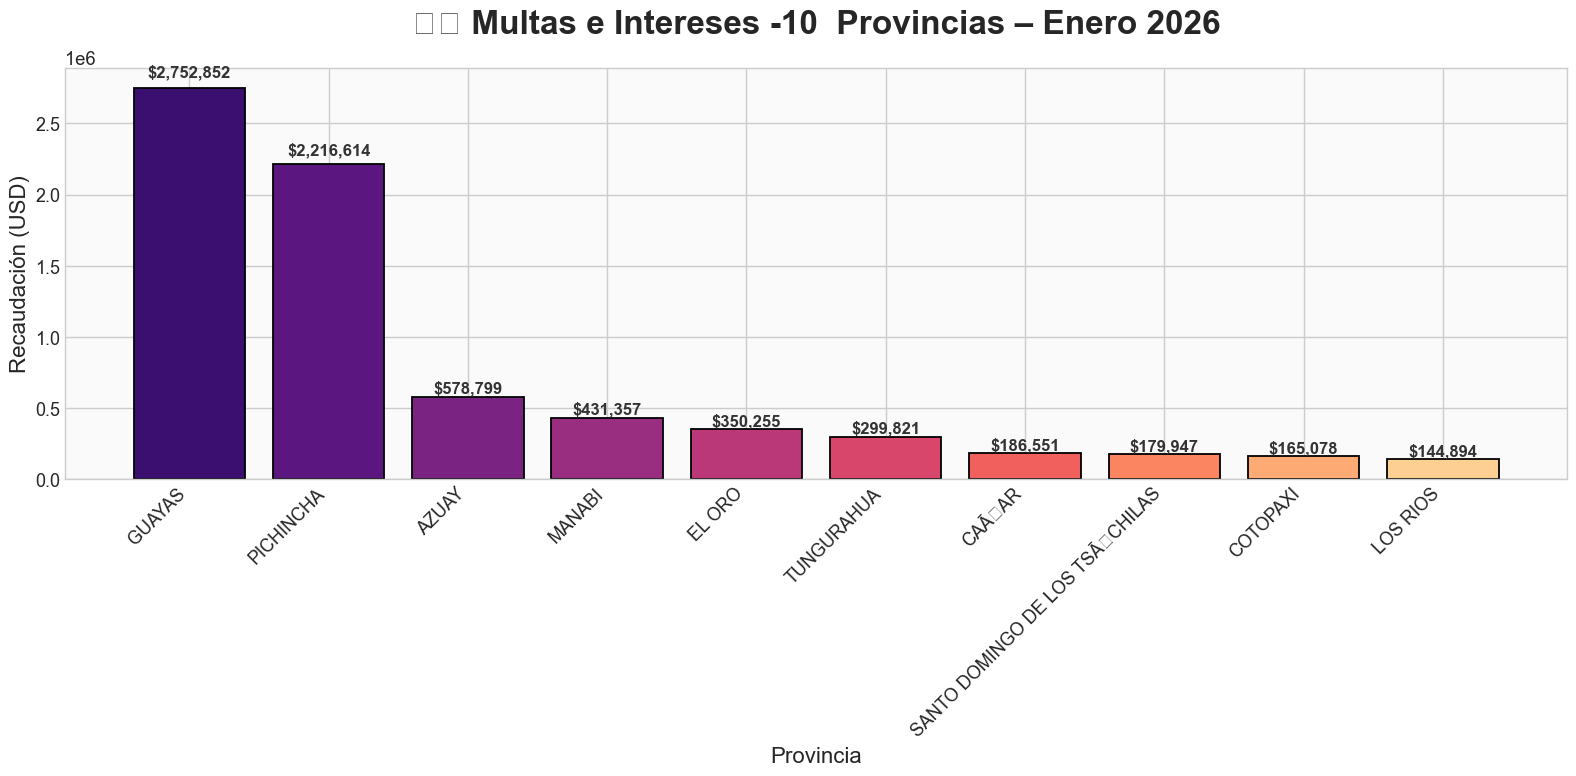

Gráfico guardado como: multas_intereses_provincia_estilizado.png


In [83]:

# === CONFIGURACIÓN DE ESTILO ===
plt.style.use("seaborn-v0_8-whitegrid")

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.facecolor'] = 'white'

# === Filtrar multas e intereses ===
multas_intereses = df[
    df["GRUPO_IMPUESTO"].str.contains("MULTAS|INTERESES", case=False, na=False)
]

# === Agrupar por provincia ===
prov_mi = (
    multas_intereses.groupby("PROVINCIA")["VALOR_RECAUDADO"]
    .sum()
    .sort_values(ascending=False).head(10)
)

# === Graficar (versión mejorada) ===
fig, ax = plt.subplots(figsize=(16, 8))

# Crear colores degradados profesionales
colors = plt.cm.magma(np.linspace(0.2, 0.9, len(prov_mi)))

bars = ax.bar(prov_mi.index, prov_mi.values,
              color=colors, edgecolor="black", linewidth=1.3)

# Título elegante
ax.set_title(
    "⚖️ Multas e Intereses -10  Provincias – Enero 2026",
    fontsize=24, fontweight="bold", pad=25
)

ax.set_ylabel("Recaudación (USD)", fontsize=16)
ax.set_xlabel("Provincia", fontsize=16)

plt.xticks(rotation=45, ha="right", fontsize=13)
plt.yticks(fontsize=13)

# Fondo estilo dashboard
ax.set_facecolor("#FAFAFA")

# Etiquetas encima de las barras
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + (height * 0.02),
        f"${height:,.0f}",
        ha="center", va="bottom",
        fontsize=12, fontweight="bold", color="#333"
    )

plt.tight_layout()

# Guardar en alta calidad
plt.savefig("multas_intereses_provincia_estilizado.png", dpi=300, bbox_inches="tight")
plt.show()

print("Gráfico guardado como: multas_intereses_provincia_estilizado.png")


## Comparativa IVA vs Renta vs Vehículos

C:\Users\mmunoz\AppData\Local\Temp\ipykernel_26716\1607318877.py:60: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\mmunoz\AppData\Local\Temp\ipykernel_26716\1607318877.py:62: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.savefig("comparativa_iva_renta_vehiculos_estilizado.png", dpi=300, bbox_inches="tight")
C:\Users\mmunoz\AppData\Local\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


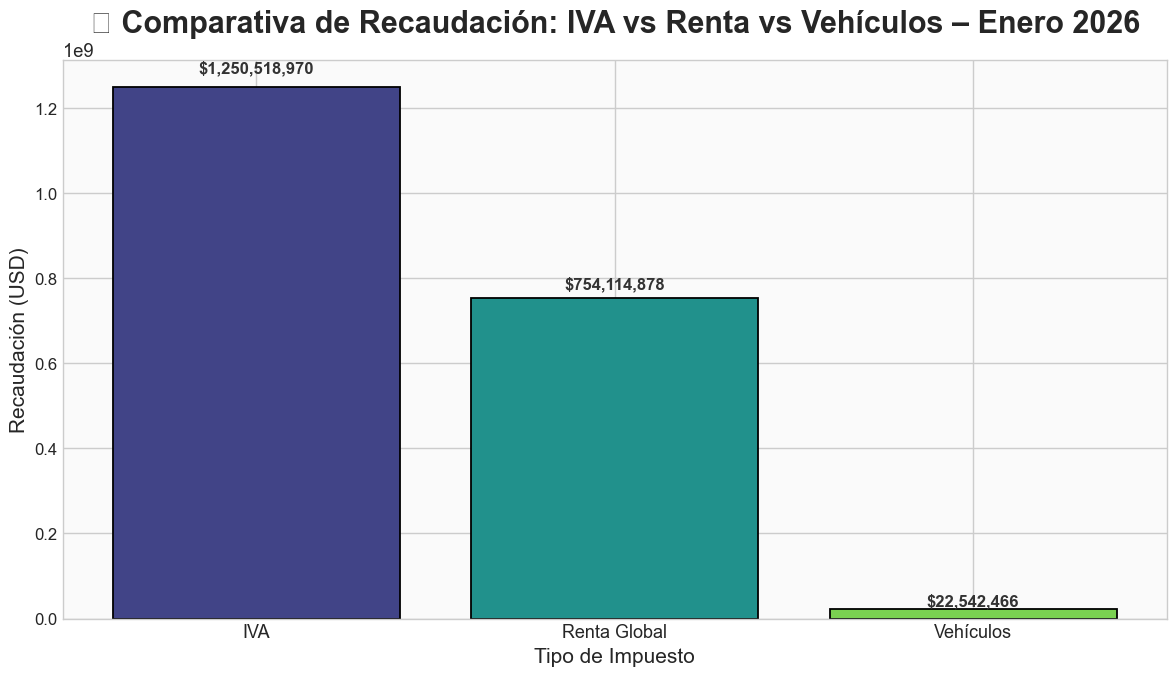

Gráfico guardado como: comparativa_iva_renta_vehiculos_estilizado.png


In [84]:
plt.style.use("seaborn-v0_8-whitegrid")

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.facecolor'] = 'white'

#Filtrar recaudación por grupos

# IVA (cualquier variante)
iva_df = df[df["GRUPO_IMPUESTO"].str.contains("VALOR AGREGADO", case=False, na=False)]

# Renta (todas las variantes)
renta_df = df[df["GRUPO_IMPUESTO"].str.contains("RENTA", case=False, na=False)]

# Vehículos
veh_df = df[df["GRUPO_IMPUESTO"].str.contains("VEHICULOS", case=False, na=False)]

# === Totales por categoría ===
totales = {
    "IVA": iva_df["VALOR_RECAUDADO"].sum(),
    "Renta Global": renta_df["VALOR_RECAUDADO"].sum(),
    "Vehículos": veh_df["VALOR_RECAUDADO"].sum()
}

serie_tot = pd.Series(totales).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))

colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(serie_tot)))

bars = ax.bar(
    serie_tot.index, serie_tot.values,
    color=colors, edgecolor="black", linewidth=1.3
)

ax.set_title(
    "📊 Comparativa de Recaudación: IVA vs Renta vs Vehículos – Enero 2026",
    fontsize=22, fontweight="bold", pad=20
)

ax.set_ylabel("Recaudación (USD)", fontsize=15)
ax.set_xlabel("Tipo de Impuesto", fontsize=15)

plt.xticks(rotation=0, fontsize=13)
plt.yticks(fontsize=12)

ax.set_facecolor("#FAFAFA")

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + (height * 0.02),
        f"${height:,.0f}",
        ha="center", va="bottom",
        fontsize=12, fontweight="bold", color="#333"
    )

plt.tight_layout()

plt.savefig("comparativa_iva_renta_vehiculos_estilizado.png", dpi=300, bbox_inches="tight")
plt.show()

print("Gráfico guardado como: comparativa_iva_renta_vehiculos_estilizado.png")

Este gráfico compara tres de los grupos tributarios más relevantes:

- IVA (todas sus variantes: mensual, semestral, importaciones)
- Impuesto a la Renta (retenciones, personas naturales, sociedades, etc.)
- Impuesto a los Vehículos Motorizados (IVMT) + 1% transferencia

## Top 10 cantones con mayor recaudación

C:\Users\mmunoz\AppData\Local\Temp\ipykernel_26716\1589225665.py:54: UserWarning: Glyph 145 (\x91) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\mmunoz\AppData\Local\Temp\ipykernel_26716\1589225665.py:54: UserWarning: Glyph 127961 (\N{CITYSCAPE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\mmunoz\AppData\Local\Temp\ipykernel_26716\1589225665.py:54: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\mmunoz\AppData\Local\Temp\ipykernel_26716\1589225665.py:56: UserWarning: Glyph 145 (\x91) missing from font(s) Arial.
  plt.savefig("top10_cantones_recaudacion_estilizado.png", dpi=300, bbox_inches="tight")
C:\Users\mmunoz\AppData\Local\Temp\ipykernel_26716\1589225665.py:56: UserWarning: Glyph 127961 (\N{CITYSCAPE}) missing from font(s) Arial.
  plt.savefig("top10_cantones_recaudacion_estilizado.png", dpi=300, bbox_inches="tight")
C:\Users\mmunoz\AppData\Local\Temp\ipykernel_26716\1589225665.py:56: UserWarn

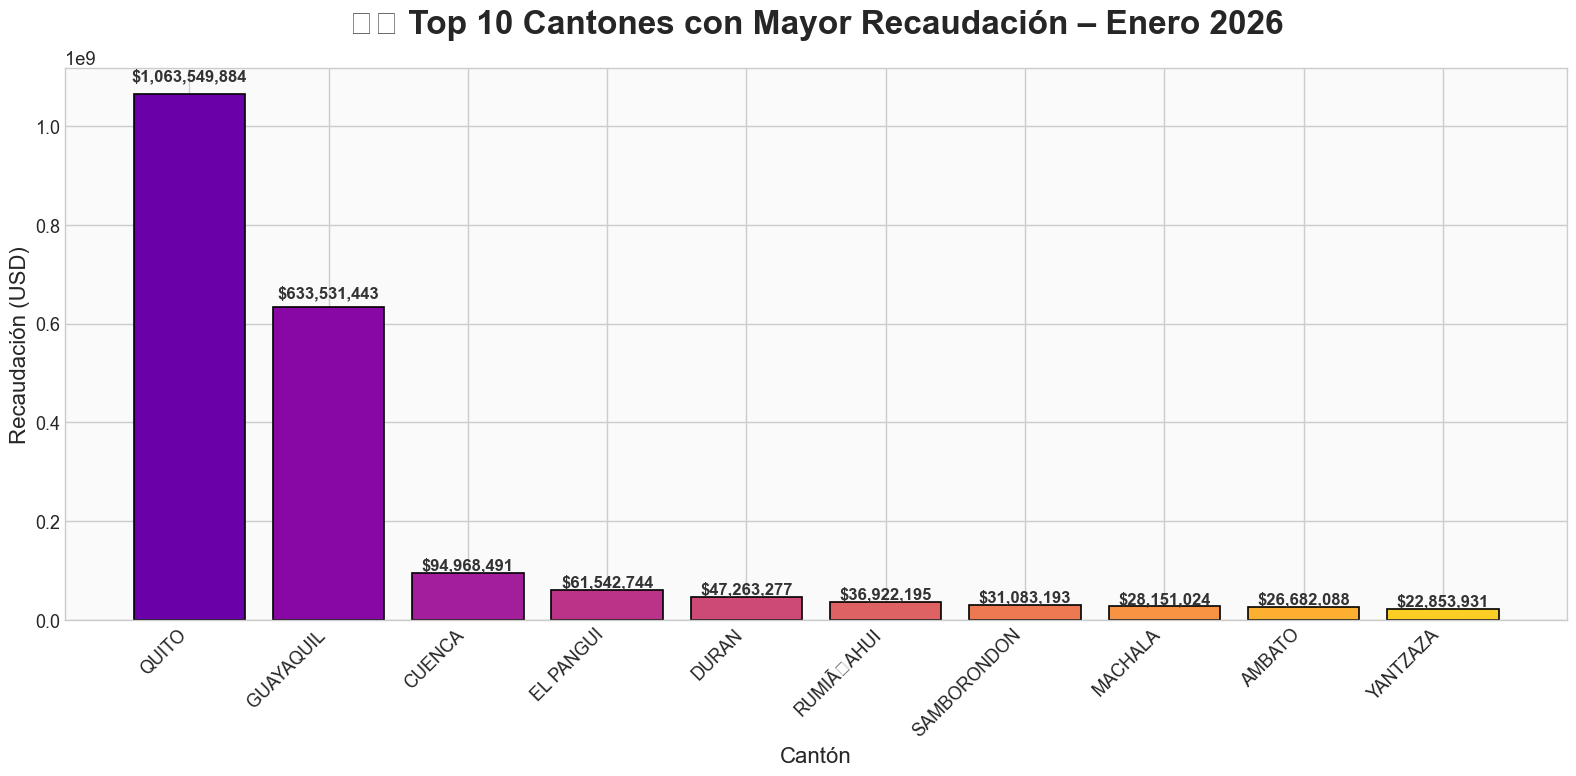

Gráfico guardado como: top10_cantones_recaudacion_estilizado.png


In [85]:
plt.style.use("seaborn-v0_8-whitegrid")

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.facecolor'] = 'white'

# === 4. Agrupar y obtener Top 10 cantones ===
top_cantones = (
    df.groupby("CANTON")["VALOR_RECAUDADO"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

fig, ax = plt.subplots(figsize=(16, 8))

colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(top_cantones)))

bars = ax.bar(
    top_cantones.index,
    top_cantones.values,
    color=colors,
    edgecolor="black",
    linewidth=1.2
)

ax.set_title(
    "🏙️ Top 10 Cantones con Mayor Recaudación – Enero 2026",
    fontsize=24, fontweight="bold", pad=25
)

ax.set_ylabel("Recaudación (USD)", fontsize=16)
ax.set_xlabel("Cantón", fontsize=16)

plt.xticks(rotation=45, ha="right", fontsize=13)
plt.yticks(fontsize=13)

ax.set_facecolor("#FAFAFA")

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + (height * 0.02),
        f"${height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
        color="#333"
    )

plt.tight_layout()

plt.savefig("top10_cantones_recaudacion_estilizado.png", dpi=300, bbox_inches="tight")
plt.show()

print("Gráfico guardado como: top10_cantones_recaudacion_estilizado.png")

In [86]:
#pip install plotly

In [87]:
import pandas as pd
import plotly.express as px

# === 1. Cargar y limpiar datos ===
df = pd.read_csv("sri_recaudacion_2026.csv", sep=";", dtype=str, encoding="latin1")

df["VALOR_RECAUDADO"] = (
    df["VALOR_RECAUDADO"]
    .str.replace(".", "", regex=False)
    .str.replace(",", ".", regex=False)
)
df["VALOR_RECAUDADO"] = pd.to_numeric(df["VALOR_RECAUDADO"], errors="coerce")

# === 2. Agrupar por cantón (Top 10) ===
top_cantones = (
    df.groupby("CANTON")["VALOR_RECAUDADO"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

fig = px.bar(
    top_cantones,
    x="CANTON",
    y="VALOR_RECAUDADO",
    title="🏙️ Top 10 Cantones con Mayor Recaudación – Enero 2026 (Interactivo)",
    color="VALOR_RECAUDADO",
    color_continuous_scale="Plasma",
    hover_data={"VALOR_RECAUDADO": ":,.2f"},
)

fig.update_layout(
    title_font_size=26,
    template="plotly_white",
    xaxis_title="Cantón",
    yaxis_title="Recaudación (USD)",
    xaxis_tickangle=-45,
    coloraxis_colorbar=dict(title="Recaudación"),
    showlegend=False,
)

fig.update_traces(
    text=top_cantones["VALOR_RECAUDADO"].apply(lambda x: f"${x:,.0f}"),
    textposition="outside"
)

fig.show()

fig.write_html("top10_cantones_interactivo.html")

print("Archivo interactivo guardado como: top10_cantones_interactivo.html")

Archivo interactivo guardado como: top10_cantones_interactivo.html
